## Introduction
name : Fauzi Maulana Nugraha

batch : 40

objective : Video game analysis to make a `steam rating` metrics. in order to identify 'hidden gems' with extremly high ratings, but very low owner counts

Models : Models used will be KNN, SVM, Decision tree, random forest, and gradient boosting that will be impelemnted into a pipeline 

metrics evaluation : using  confusion matrix to show predictions and lists of steam games from model predict

## Import Library

In [1]:
import pandas as pd
import numpy as np

#  Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#  Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

#  Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

#  Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Model saving
import pickle

## data loading

In [2]:
df = pd.read_csv('steam_games_dataset.csv')
df

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,444720,Inexistence,Jonathan BRASSAUD,Jonathan BRASSAUD,NaN,242,126,0,"50,000 .. 100,000",279,0,313,0,299,299,0,0
9996,649600,Swords and Sandals 2 Redux,Whiskeybarrel Studios,eGames.com,NaN,429,117,0,"50,000 .. 100,000",333,0,432,0,999,999,0,4
9997,1122120,STATIONflow,DMM GAMES,DMM GAMES,NaN,414,66,0,"50,000 .. 100,000",984,0,984,0,1799,1799,0,6
9998,424640,Karaski: What Goes Up...,Unbound Creations,Unbound Creations,NaN,51,8,0,"50,000 .. 100,000",0,0,0,0,1199,1199,0,0


In [3]:
df.head(10)

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819
5,1938090,Call of Duty: Modern Warfare II,"Treyarch, Raven Software, Beenox, High Moon St...",Activision,NaN,419594,294520,0,"50,000,000 .. 100,000,000",5397,639,738,324,3849,6999,45,67419
6,1063730,New World: Aeternum,Amazon Games,Amazon Games,NaN,196798,90080,0,"50,000,000 .. 100,000,000",10588,18,3762,18,5999,5999,0,5583
7,2358720,Black Myth: Wukong,Game Science,Game Science,NaN,1111720,38378,0,"50,000,000 .. 100,000,000",3268,524,2838,202,5999,5999,0,15004
8,271590,Grand Theft Auto V Legacy,Rockstar North,Rockstar Games,NaN,1739980,250576,0,"50,000,000 .. 100,000,000",13153,699,5454,49,0,0,0,67851
9,550,Left 4 Dead 2,Valve,Valve,NaN,940221,23762,0,"50,000,000 .. 100,000,000",2479,352,543,71,999,999,0,25122


In [4]:
df.tail(10)

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
9990,1841220,The Devils - A Visual Novel Of WWII,William Volk,Deep State Games,NaN,2,0,0,"50,000 .. 100,000",0,0,0,0,199,199,0,0
9991,311870,Super Trench Attack!,Retro Army Limited,paulstephendavis,NaN,1156,119,0,"50,000 .. 100,000",214,0,205,0,499,499,0,0
9992,1144800,Drop In - VR F2P,"Wild Ox Studios, Tim van Kan",Wild Ox Studios,NaN,472,97,0,"50,000 .. 100,000",0,0,0,0,0,0,0,1
9993,2216130,沉默的蟋蟀,蓬莱飞鱼工作室,噪点游戏 ZAO GAMES,NaN,1084,118,0,"50,000 .. 100,000",1137,0,984,0,1499,1499,0,45
9994,1583690,Elijah and the Out of this World Adventure,PDS Games,PDS Games,NaN,13,0,0,"50,000 .. 100,000",0,0,0,0,399,399,0,0
9995,444720,Inexistence,Jonathan BRASSAUD,Jonathan BRASSAUD,NaN,242,126,0,"50,000 .. 100,000",279,0,313,0,299,299,0,0
9996,649600,Swords and Sandals 2 Redux,Whiskeybarrel Studios,eGames.com,NaN,429,117,0,"50,000 .. 100,000",333,0,432,0,999,999,0,4
9997,1122120,STATIONflow,DMM GAMES,DMM GAMES,NaN,414,66,0,"50,000 .. 100,000",984,0,984,0,1799,1799,0,6
9998,424640,Karaski: What Goes Up...,Unbound Creations,Unbound Creations,NaN,51,8,0,"50,000 .. 100,000",0,0,0,0,1199,1199,0,0
9999,598060,Slasher's Keep,Damian Schloter,Damian Schloter,NaN,1791,355,0,"50,000 .. 100,000",423,0,396,0,1399,1399,0,6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            10000 non-null  int64  
 1   name             10000 non-null  object 
 2   developer        9967 non-null   object 
 3   publisher        9946 non-null   object 
 4   score_rank       5 non-null      float64
 5   positive         10000 non-null  int64  
 6   negative         10000 non-null  int64  
 7   userscore        10000 non-null  int64  
 8   owners           10000 non-null  object 
 9   average_forever  10000 non-null  int64  
 10  average_2weeks   10000 non-null  int64  
 11  median_forever   10000 non-null  int64  
 12  median_2weeks    10000 non-null  int64  
 13  price            10000 non-null  int64  
 14  initialprice     10000 non-null  int64  
 15  discount         10000 non-null  int64  
 16  ccu              10000 non-null  int64  
dtypes: float64(1)

In [6]:
df.describe()

,appid,score_rank,positive,negative,userscore,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
count,1.000000e+04,5.0,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,9.008700e+05,99.0,1.214202e+04,1.948096e+03,0.036000,1023.689500,112.496300,515.001700,118.949000,1131.326700,1284.141500,8.675800,5.643178e+02
std,7.290494e+05,1.0,9.536926e+04,1.812977e+04,1.671581,4193.287962,638.473189,3508.429257,707.962801,1299.903805,1364.327698,23.476133,1.128781e+04
min,1.000000e+01,98.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,3.365875e+05,98.0,4.310000e+02,1.100000e+02,0.000000,145.000000,0.000000,79.750000,0.000000,99.000000,199.000000,0.000000,0.000000e+00
50%,6.551300e+05,99.0,1.514500e+03,2.950000e+02,0.000000,310.000000,0.000000,210.000000,0.000000,719.000000,999.000000,0.000000,5.000000e+00
75%,1.333238e+06,100.0,4.996750e+03,8.712500e+02,0.000000,817.250000,6.000000,406.000000,6.000000,1799.000000,1999.000000,0.000000,4.500000e+01
max,3.605460e+06,100.0,7.642084e+06,1.173003e+06,95.000000,263340.000000,20080.000000,269193.000000,20080.000000,14999.000000,14999.000000,95.000000,1.013936e+06


## EDA

In [7]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

appid                 0
name                  0
developer            33
publisher            54
score_rank         9995
positive              0
negative              0
userscore             0
owners                0
average_forever       0
average_2weeks        0
median_forever        0
median_2weeks         0
price                 0
initialprice          0
discount              0
ccu                   0
dtype: int64

Adding unknown for null values developer and publisher, since the missing values from both of the values only have 0.33 % ~ 0.55 % (less than 1 %) missing from the dataset.

In [8]:
# adding unknown category for missing values in 'developer' and 'publisher'
df['developer'] = df['developer'].fillna('Unknown')
df['publisher'] = df['publisher'].fillna('Unknown')


Here, i will check if its already filled with 'Unkown' on Nan Values

In [9]:
df[df['developer'] == 'Unknown'].sample(n=5)

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
7343,248490,1953 - KGB Unleashed,Unknown,United Independent Entertainment,NaN,369,267,0,"100,000 .. 200,000",70,0,96,0,299,299,0,0
8374,252370,The Shivah,Unknown,Wadjet Eye Games,NaN,674,157,0,"100,000 .. 200,000",105,0,123,0,499,499,0,1
7031,547010,Terminal Hacker,Unknown,Achpile,NaN,86,75,0,"100,000 .. 200,000",18,0,29,0,0,0,0,0
4686,616090,龙魂时刻,Unknown,Jenny Bee Presents,NaN,465,850,0,"200,000 .. 500,000",113,0,52,0,0,0,0,0
9505,906390,Return.,Unknown,PsychoFlux Entertainment,NaN,867,90,0,"50,000 .. 100,000",21,0,26,0,99,99,0,0


In [10]:
df[df['publisher'] == 'Unknown'].sample(n=5)

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
6843,754320,Pixel Noir,SWDTech Games,Unknown,NaN,58,24,0,"100,000 .. 200,000",0,0,0,0,2499,2499,0,1
3338,220660,StarDrive,Zero Sum Games,Unknown,NaN,658,815,0,"200,000 .. 500,000",1123,0,304,0,2999,2999,0,4
4976,438010,PulseCharge,Endless Project Games,Unknown,NaN,93,92,0,"200,000 .. 500,000",231,0,245,0,99,99,0,0
6663,2550,RIP - Trilogy,Elephant Games,Unknown,NaN,204,136,0,"100,000 .. 200,000",83,0,153,0,499,499,0,0
7694,200910,Before the Echo,Iridium Studios,Unknown,NaN,1235,193,0,"100,000 .. 200,000",270,0,149,0,499,499,0,0


In [11]:
# check for duplicates
duplicate_count = df.duplicated().sum()
duplicate_count

50

same from the previous reason. this time, the duplicate values are only 0.5 % (less than 1%). i can safely remove deuplicates.

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

0

here we can check the distribution of prices on dataset

In [14]:
avg_price = df['price'].mean()
print(f'Average steam game Price: ${avg_price/100:.2f}')

Average steam game Price: $11.32


C:\Users\Fauzi Maulana\AppData\Local\Temp\ipykernel_5968\2241450525.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_usd'] = df['price'] / 100.0


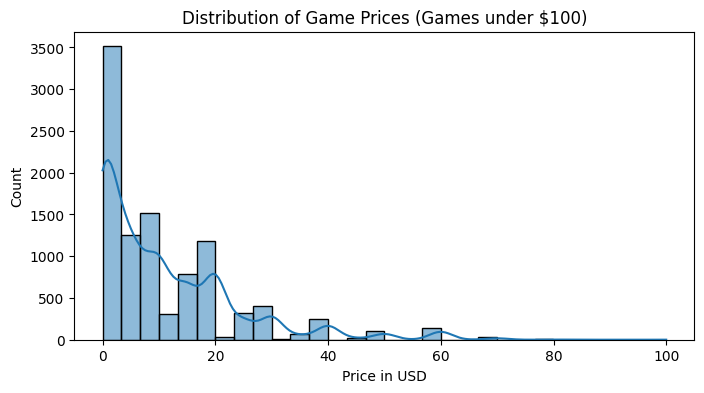

In [15]:
df['price_usd'] = df['price'] / 100.0
plt.figure(figsize=(8, 4))
sns.histplot(df[df['price_usd'] < 100]['price_usd'], bins=30, kde=True)
plt.title('Distribution of Game Prices (Games under $100)')
plt.xlabel('Price in USD')
plt.ylabel('Count')
plt.show()

Since Score rank is empty on 99% of the dataset, a new score will be determined on feature engineering. here we can drop the said feature first

In [16]:
df = df.drop(columns=['score_rank'], errors='ignore')
df.sample(10)

,appid,name,developer,publisher,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,price_usd
3113,452060,Caveblazers,Deadpan Games,Yogscast Games,3762,632,0,"200,000 .. 500,000",788,0,130,0,999,999,0,32,9.99
2481,351920,Crazy Machines 3,Fakt Software,Daedalic Entertainment,9350,554,0,"500,000 .. 1,000,000",166,0,104,0,999,999,0,11,9.99
6875,662960,Mysteria ~Occult Shadows~,U-Secret Studio,SakuraGame,2206,1193,0,"100,000 .. 200,000",931,0,136,0,1299,1299,0,3,12.99
3479,344130,Cataegis : The White Wind,Acido Cinza,KISS ltd,435,122,0,"200,000 .. 500,000",330,0,318,0,499,499,0,0,4.99
1448,19680,Alice: Madness Returns,Spicy Horse Games,Electronic Arts,21729,2358,0,"1,000,000 .. 2,000,000",555,80,200,142,999,999,0,260,9.99
144,30,Day of Defeat,Valve,Valve,6414,688,0,"5,000,000 .. 10,000,000",1040,0,14,0,499,499,0,87,4.99
404,881020,Granblue Fantasy: Relink,"Cygames, Inc.","Cygames, Inc.",43116,4883,0,"2,000,000 .. 5,000,000",3297,756,1856,688,3999,3999,0,996,39.99
3687,835960,The Talos Principle 2,Croteam,Devolver Digital,11357,540,0,"200,000 .. 500,000",1823,0,1869,0,2999,2999,0,149,29.99
9595,61310,Fractal: Make Blooms Not War,Cipher Prime Studios,Cipher Prime Studios,161,54,0,"50,000 .. 100,000",50,0,36,0,699,699,0,0,6.99
7604,2441270,Kill The Crows,5minlab Corp.,"5minlab Corp., KRAFTON, Inc.",2016,109,0,"100,000 .. 200,000",178,0,154,0,499,499,0,15,4.99


## Feature Engineering

labeling new score based on the sales numbers mixed with the compared positive to negative reviews.

*Partially Successful*
| Review Ratio    | Partially Successful |
| -------- | ------- |
| >= 60 | 1    |
| <= 60 | 0     |

*Success*
| Review Ratio    | Partially Successful |
| -------- | ------- |
| >= 80 | 1    |
| <= 80 | 0     |

*Very Successfull*
| Review Ratio    | Partially Successful |
| -------- | ------- |
| >= 90 | 1    |
| <= 90 | 0     |


In [17]:
# Create new features based on reviews
df['total_reviews'] = df['positive'] + df['negative']
df['review_ratio'] = df['positive'] / (df['total_reviews'] + 1)

df['partially successful'] = (df['review_ratio'] >= 0.60).astype(int)
df['success'] = (df['review_ratio'] >= 0.80).astype(int)
df['very successful'] = (df['review_ratio'] >= 0.90).astype(int)

since we dont want to find games that are below average. i will drop those games

In [18]:
df = df[df['total_reviews'] >= 20].copy()
print(f"Dataset shape after removing low-review items: {df.shape}")

Dataset shape after removing low-review items: (9441, 22)


here we can see how many labels we have on the dataset

In [19]:
print(df['partially successful'].value_counts())

print(df['success'].value_counts())

print(df['very successful'].value_counts())


partially successful
1    8340
0    1101
Name: count, dtype: int64
success
1    5381
0    4060
Name: count, dtype: int64
very successful
0    6941
1    2500
Name: count, dtype: int64


In [20]:
plot_df = pd.DataFrame({
    'Partially Successful': df['partially successful'].value_counts(),
    'Successful': df['success'].value_counts(),
    'Very Successful': df['very successful'].value_counts()
})

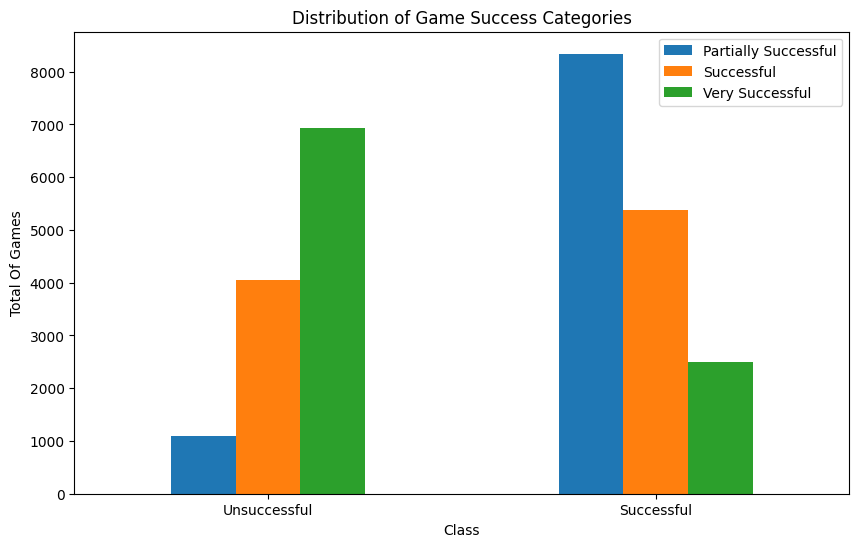

In [21]:
plot_df = plot_df.sort_index()

plot_df = plot_df.rename(index={0: 'Unsuccessful', 1: 'Successful'})
plot_df.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of Game Success Categories')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.ylabel('Total Of Games')
plt.show()


here, feature selection is implemented. `positive`, `negative`, `review_ratio`, `total_reviews`, `name`, `appid` will be dropped, since they were used to construct the target label. hence our y(target) will be `success`.
`name` and `appid` doesn't contribute meaningful predictive information.

In [22]:
x = df.drop(columns=[
    'success',
    'positive',
    'negative',
    'review_ratio',
    'total_reviews',
    'name',
    'appid',
    'partially successful',
    'very successful'
])

y = df['success']

print("Features being used:")
print(x.columns.tolist())

Features being used:
['developer', 'publisher', 'userscore', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'price_usd']


In [23]:
# train test split with stratification
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (7552, 13)
x_test shape: (1889, 13)


In [24]:
# seperate numeric and categorical features
numeric_features = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = x.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['userscore', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu', 'price_usd']
Categorical features: ['developer', 'publisher', 'owners']


In [25]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9441 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   developer        9441 non-null   object 
 1   publisher        9441 non-null   object 
 2   userscore        9441 non-null   int64  
 3   owners           9441 non-null   object 
 4   average_forever  9441 non-null   int64  
 5   average_2weeks   9441 non-null   int64  
 6   median_forever   9441 non-null   int64  
 7   median_2weeks    9441 non-null   int64  
 8   price            9441 non-null   int64  
 9   initialprice     9441 non-null   int64  
 10  discount         9441 non-null   int64  
 11  ccu              9441 non-null   int64  
 12  price_usd        9441 non-null   float64
dtypes: float64(1), int64(9), object(3)
memory usage: 1.0+ MB


In [26]:
x.head()

,developer,publisher,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,price_usd
0,Valve,Valve,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936,0.00
1,Respawn,Electronic Arts,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262,0.00
2,PUBG Corporation,"KRAFTON, Inc.",0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682,0.00
3,Pocketpair,Pocketpair,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028,29.99
4,Valve,Valve,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819,0.00


## Model Definition

here, pipeline will be defined for using 5 models. before modelling, handling missing values, scaling numerical features, and encoding categorical variables will be implemented.

In [27]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [28]:
# 5 pipelines for each model

# KNN
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# SVM
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=42))
])

# Decision Tree
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Gradient Boosting
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
]) 


## Model Training

 Training models using 5 fold cross validation

In [29]:
# knn cross validation
knn_cv = cross_val_score(
    knn_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("KNN mean F1 score:", knn_cv.mean())

KNN mean F1 score: 0.6894778618057009


In [30]:
# SVM cross validation
svm_cv = cross_val_score(
    svm_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("SVM Mean F1-Score:", svm_cv.mean())

SVM Mean F1-Score: 0.7074289128281749


In [31]:
# Decision Tree cross validation
dt_cv = cross_val_score(
    dt_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Decision Tree Mean F1-Score:", dt_cv.mean())

Decision Tree Mean F1-Score: 0.6763120156281552


In [32]:
# random forest cross validation
rf_cv = cross_val_score(
    rf_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Random Forest Mean F1-Score:", rf_cv.mean())

Random Forest Mean F1-Score: 0.7308740239818897


In [33]:
# Gradient Boosting cross validation
gb_cv = cross_val_score(
    gb_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)
print("Gradient Boosting Mean F1-Score:", gb_cv.mean())

Gradient Boosting Mean F1-Score: 0.7279502820260757


comparing model performance

In [34]:
cv_results = pd.DataFrame({
    'Model': [
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Mean F1-Score': [
        knn_cv.mean(),
        svm_cv.mean(),
        dt_cv.mean(),
        rf_cv.mean(),
        gb_cv.mean()
    ]
})

cv_results.sort_values(
by='Mean F1-Score',
ascending=False
)

,Model,Mean F1-Score
3,Random Forest,0.730874
4,Gradient Boosting,0.727950
1,SVM,0.707429
0,KNN,0.689478
2,Decision Tree,0.676312


From the results above we can determine that the best model for this study case is random forest, with highes mean F1-Score

Here, Hyperparameter for random forest with 5-fold cross-validation tuning is applied using GridSearchCV to find the optimal parameter combination

In [35]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['userscore',
                                                                          'average_forever',
                                                                          'average_2weeks',
                                                                          'median_forever',
                                                                          'median_2weeks',
                                                                          'price',
                                                                          'initialprice',
                                                                          'discount',
                                                                          'ccu',
                                                                          'price_usd']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('...',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['developer',
                                                                          'publisher',
                                                                          'owners'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [36]:
# check the best parameters
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [37]:
# check the best f1 score
print("Best F1-Score from Grid Search:", grid_search.best_score_)

Best F1-Score from Grid Search: 0.7348317003588338


In [38]:
# comparing before and after tuning
print(f"Random Forest Mean F1-Score before tuning: {rf_cv.mean():.4f}")
print(f"Random Forest Mean F1-Score after tuning: {grid_search.best_score_:.4f}")

Random Forest Mean F1-Score before tuning: 0.7309
Random Forest Mean F1-Score after tuning: 0.7348


## Model Evaluation

In [39]:
# Use the tuned model to predict on the test set
final_model = grid_search.best_estimator_
y_pred = final_model.predict(x_test)

# Full report — shows precision, recall, f1 for each class
print(classification_report(y_test, y_pred, target_names=["Not Hidden Gem", "Hidden Gem"]))

                precision    recall  f1-score   support

Not Hidden Gem       0.64      0.57      0.60       812
    Hidden Gem       0.70      0.75      0.73      1077

      accuracy                           0.68      1889
     macro avg       0.67      0.66      0.66      1889
  weighted avg       0.67      0.68      0.67      1889



Confusion matrix is implemented to show how many predictions were correct or wrong based on the predictions

<Figure size 600x500 with 0 Axes>

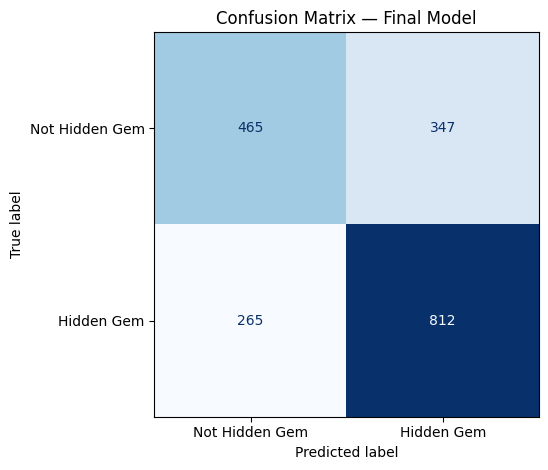

In [40]:
# Confusion matrix shows how many predictions were right or wrong
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Not Hidden Gem", "Hidden Gem"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Final Model")
plt.tight_layout()
plt.show()

since evaluation metrics is just a prediction values. several examples were shown to justify wether the model predicted the game successfuly with at least `Positive` reviews on steam to better understand the model behaviour.

games that has been predicted with the model, predicted as successfull with the highes confidence score





In [41]:
# Probability that a game is successful (class 1)
success_prob = final_model.predict_proba(x_test)[:, 1]

results = x_test.copy()

results['Game Name'] = df.loc[x_test.index, 'name']
results['Actual'] = y_test
results['Predicted'] = y_pred
results['Success Probability'] = success_prob

# Only games predicted as successful
top_hidden_gems = results[results['Predicted'] == 1]

# Sort by highest probability
top_hidden_gems = top_hidden_gems.sort_values(
    by='Success Probability',
    ascending=False
)

top_hidden_gems[
    ['Game Name', 'Success Probability']
].head(10)

,Game Name,Success Probability
699,Kingdoms and Castles,0.986258
65,Schedule I,0.982036
5293,Tape to Tape,0.977250
268,Plants vs. Zombies GOTY Edition,0.976889
249,Frostpunk,0.976571
1407,Baba Is You,0.976175
640,TCG Card Shop Simulator,0.975786
256,FTL: Faster Than Light,0.974375
212,DAVE THE DIVER,0.974077
259,Enter the Gungeon,0.973536


## Model Saving

In [42]:
with open('steam_success_rf_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Model saved!")

Model saved!
